# Sentiment Analysis — Bluesky US Election 2024

Four sentiment methods applied to Bluesky posts, in order of complexity:

| # | Method | Type | Output |
|---|---|---|---|
| 1 | **VADER** | Rule-based lexicon | `vader_compound` ∈ [−1, +1] |
| 2 | **Twitter-RoBERTa** | Pre-trained transformer (fine-tuned on tweets) | `roberta_sentiment` = pos − neg probability ∈ [−1, +1] |
| 3 | **TextBlob** | Pattern lexicon | `tb_polarity` ∈ [−1, +1], `tb_subjectivity` ∈ [0, 1] |
| 4 | **NRCLex** | Emotion lexicon | 8 emotion dimensions |

Each section: method explanation → score distribution → scores by buzz group → scores over time.

**Input:** `Data/2_Silver/Bluesky/cleaned_data.csv`  
**Output:** `Data/2_Silver/Bluesky/sentiment_bluesky.csv`

## 0. Setup

In [29]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# All paths relative to the notebook location (Descriptive/2_bluesky/)
# house_style.py is at the project root = two levels up
sys.path.insert(0, os.path.abspath('../..'))

from house_style import (
    apply_style, REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    TEXT_PRIMARY, TEXT_MUTED, BG_DARK, BG_PANEL
)
apply_style()

DATA_PATH  = '../../Data/2_Silver/Bluesky/cleaned_data.csv'
GLOVE_PATH = '../../Pre-trained-models/glove.6B/glove.6B.100d.txt'
OUT_PATH   = '../../Data/2_Silver/Bluesky/sentiment_bluesky.csv'

# Colours
BUZZ_COLORS = {
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': NEUTRAL,
}
BUZZ_ORDER  = ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
POL_COLORS  = {'Positive': '#2ecc71', 'Neutral': TEXT_MUTED, 'Negative': REPUBLICAN}
PURPLE      = '#9b5de5'

EMOTION_COLORS = {
    'fear': REPUBLICAN, 'anger': '#e67e22', 'anticipation': ACCENT,
    'trust': '#2ecc71', 'surprise': NEUTRAL, 'sadness': DEMOCRAT,
    'disgust': '#9b59b6', 'joy': '#FFD700',
}
EMOTION_COLS = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']

# Key events
EVENTS = [
    ('2024-07-13', 'Trump shot'),
    ('2024-07-21', 'Biden drops out'),
    ('2024-09-10', 'Harris-Trump debate'),
    ('2024-09-15', '2nd assassination attempt'),
]

def add_events(ax):
    for date, label in EVENTS:
        ax.axvline(pd.Timestamp(date), color='#FFFF00', linewidth=1.2, linestyle=':', alpha=0.85)
        ax.text(pd.Timestamp(date), ax.get_ylim()[1], f' {label}',
                color='#FFFF00', fontsize=7.5, va='top', rotation=90)

print('Setup complete.')

Setup complete.


## 1. Load data

In [30]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df['date']      = pd.to_datetime(df['date']).dt.normalize()
df['text_norm'] = df['text_norm'].fillna('')
df['text']      = df['text'].fillna('')

# Recreate buzz_group if missing
if 'buzz_group' not in df.columns or df['buzz_group'].isna().all():
    text_l = df['text_norm'].str.lower()
    df['buzz_group'] = 'ElectionBuzz'
    df.loc[text_l.str.contains('trump'),  'buzz_group'] = 'TrumpBuzz'
    df.loc[text_l.str.contains('harris'), 'buzz_group'] = 'HarrisBuzz'

# Filter to project date range
df = df[(df['date'] >= '2024-07-05') & (df['date'] <= '2024-11-04')].reset_index(drop=True)

print(f'Posts     : {len(df):,}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(df['buzz_group'].value_counts())

Posts     : 25,472
Date range: 2024-07-05 → 2024-11-04
buzz_group
ElectionBuzz    12642
TrumpBuzz        7497
HarrisBuzz       5333
Name: count, dtype: int64


---
## 2. VADER

**What it is:** VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based lexicon
designed specifically for social media text. It handles capitalisation, punctuation, emojis,
and degree modifiers (e.g. *very good* vs *good*).

**Score:** `vader_compound` ∈ [−1, +1]. Threshold: ≥ +0.05 = Positive, ≤ −0.05 = Negative, else Neutral.  
**Why first:** VADER is the standard baseline for short social media text and requires no training data or model loading.

In [31]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()
scores = df['text'].apply(vader.polarity_scores)

df['vader_compound'] = scores.apply(lambda s: s['compound'])
df['vader_pos']      = scores.apply(lambda s: s['pos'])
df['vader_neu']      = scores.apply(lambda s: s['neu'])
df['vader_neg']      = scores.apply(lambda s: s['neg'])
df['vader_label']    = pd.cut(
    df['vader_compound'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['Negative', 'Neutral', 'Positive']
)

print(df['vader_compound'].describe().round(3))
print('\nPolarity distribution:')
print(df['vader_label'].value_counts())

count    25472.000
mean         0.049
std          0.508
min         -0.993
25%         -0.338
50%          0.000
75%          0.457
max          0.999
Name: vader_compound, dtype: float64

Polarity distribution:
vader_label
Positive    10619
Negative     8376
Neutral      6477
Name: count, dtype: int64


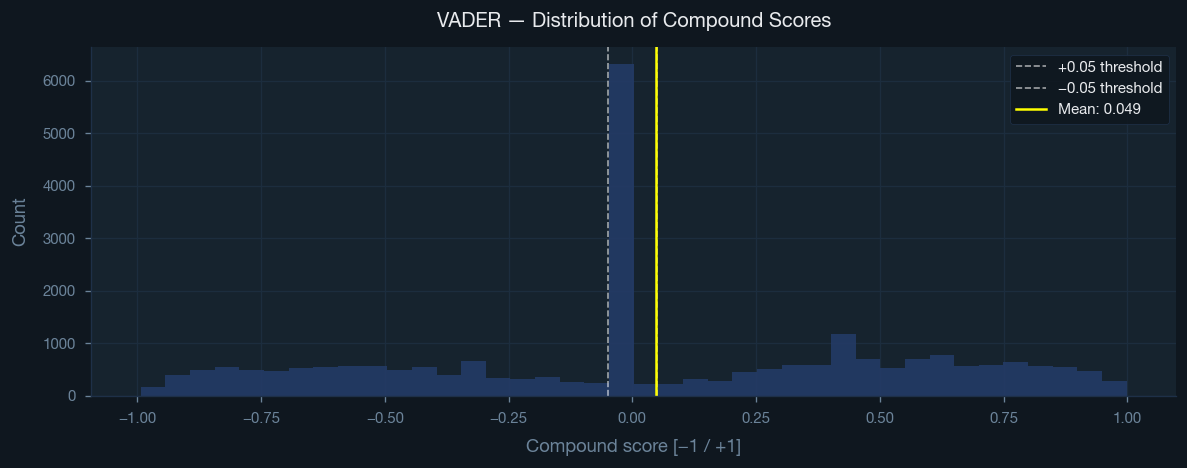

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
ax.hist(df['vader_compound'], bins=40, color=ACCENT, alpha=0.85, edgecolor='none')
ax.axvline( 0.05, color='white', linestyle='--', linewidth=1, alpha=0.6, label='+0.05 threshold')
ax.axvline(-0.05, color='white', linestyle='--', linewidth=1, alpha=0.6, label='−0.05 threshold')
ax.axvline(df['vader_compound'].mean(), color='yellow', linewidth=1.5,
           label=f'Mean: {df["vader_compound"].mean():.3f}')
ax.set_title('VADER — Distribution of Compound Scores', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_xlabel('Compound score [−1 / +1]', color=TEXT_MUTED)
ax.set_ylabel('Count', color=TEXT_MUTED)
ax.tick_params(colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()

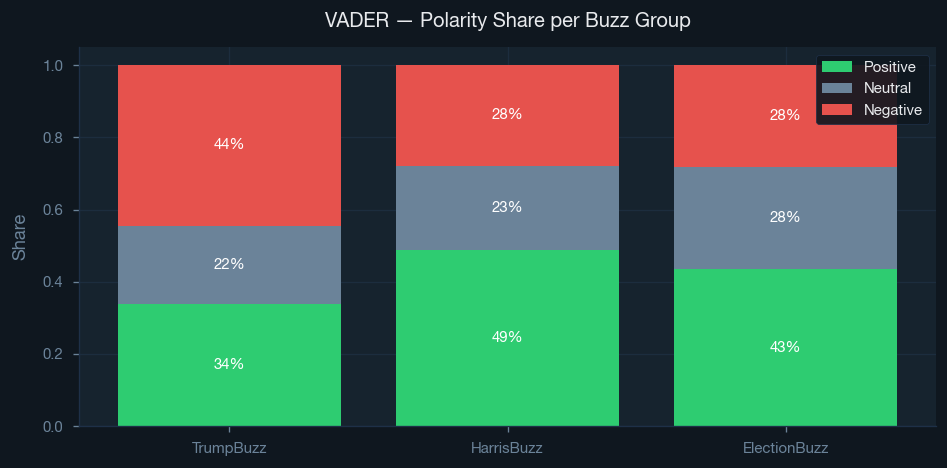

In [33]:
label_shares = (
    df.groupby(['buzz_group', 'vader_label']).size()
      .unstack(fill_value=0)
      .apply(lambda r: r / r.sum(), axis=1)
      .reindex(BUZZ_ORDER)[['Positive', 'Neutral', 'Negative']]
)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
x, bottom = np.arange(len(BUZZ_ORDER)), np.zeros(len(BUZZ_ORDER))
for label, color in POL_COLORS.items():
    vals = label_shares[label].values
    ax.bar(x, vals, bottom=bottom, color=color, label=label, edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(x[i], b + v/2, f'{v:.0%}', ha='center', va='center', color='white', fontsize=9)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(BUZZ_ORDER, color=TEXT_MUTED)
ax.set_ylabel('Share', color=TEXT_MUTED)
ax.set_title('VADER — Polarity Share per Buzz Group', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.tick_params(colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY, loc='upper right')
plt.tight_layout()
plt.show()

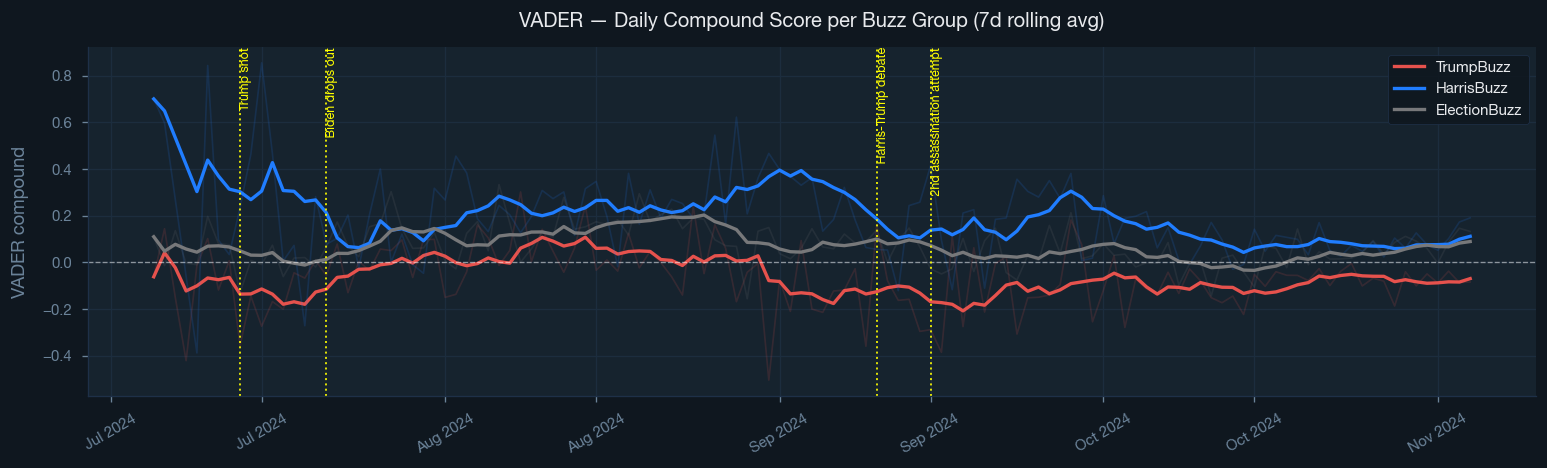

In [34]:
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
for group, color in BUZZ_COLORS.items():
    daily = df[df['buzz_group'] == group].groupby('date')['vader_compound'].mean()
    roll  = daily.rolling(7, min_periods=1).mean()
    ax.plot(daily.index, daily.values, color=color, alpha=0.15, linewidth=1)
    ax.plot(roll.index,  roll.values,  color=color, linewidth=2, label=group)
ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
add_events(ax)
ax.set_title('VADER — Daily Compound Score per Buzz Group (7d rolling avg)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_ylabel('VADER compound', color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30, colors=TEXT_MUTED)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()

---
## 3. Twitter-RoBERTa

**What it is:** `cardiffnlp/twitter-roberta-base-sentiment-latest` is a RoBERTa transformer
fine-tuned on ~124 million tweets. Unlike VADER and TextBlob (which match words against a fixed lexicon),
RoBERTa reads the full sentence in context — it understands that *"not great"* is negative,
even though *"great"* alone is positive.

**Output:** Probabilities for Negative / Neutral / Positive. We take `score_positive − score_negative`
as a single sentiment score ∈ [−1, +1], analogous to VADER's compound score.

**Why here:** This is the genuine pre-trained model in the pipeline — trained on social media text
that closely matches Bluesky posts in length and style.

In [35]:
from transformers import pipeline

print('Loading Twitter-RoBERTa model (downloads once, then cached)...')
roberta = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    tokenizer='cardiffnlp/twitter-roberta-base-sentiment-latest',
    max_length=512,
    truncation=True,
    device=-1   # CPU; change to 0 if you have a GPU
)
print('Model loaded.')

Loading Twitter-RoBERTa model (downloads once, then cached)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2785.75it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [36]:
def roberta_scores(text):
    """Return (label, positive_prob, negative_prob, neutral_prob) for a text."""
    try:
        # Run model — returns list with best label + score
        result = roberta(str(text)[:512])[0]
        label  = result['label'].lower()   # 'positive', 'neutral', or 'negative'
    except Exception:
        return 'neutral', 0.0, 0.0, 1.0

    # Get all three class probabilities in one forward pass
    results = roberta(str(text)[:512], top_k=None)
    probs   = {r['label'].lower(): r['score'] for r in results}
    return (
        label,
        probs.get('positive', 0.0),
        probs.get('negative', 0.0),
        probs.get('neutral',  0.0),
    )

print('Running Twitter-RoBERTa on all posts (this takes a few minutes)...')

# Process in batches for speed
BATCH_SIZE = 64
texts  = df['text'].fillna('').tolist()
labels, pos_probs, neg_probs, neu_probs = [], [], [], []

for i in range(0, len(texts), BATCH_SIZE):
    batch   = [str(t)[:512] for t in texts[i:i+BATCH_SIZE]]
    results = roberta(batch, top_k=None)
    for r in results:
        probs = {x['label'].lower(): x['score'] for x in r}
        pos_probs.append(probs.get('positive', 0.0))
        neg_probs.append(probs.get('negative', 0.0))
        neu_probs.append(probs.get('neutral',  0.0))
        labels.append(max(probs, key=probs.get).capitalize())
    if (i // BATCH_SIZE) % 10 == 0:
        print(f'  {i}/{len(texts)} posts processed...')

df['roberta_pos']       = pos_probs
df['roberta_neg']       = neg_probs
df['roberta_neu']       = neu_probs
df['roberta_sentiment'] = df['roberta_pos'] - df['roberta_neg']  # compound-style score
df['roberta_label']     = labels

print(f'\nDone. {len(df):,} posts scored.')
print(df['roberta_label'].value_counts())
print(f'Mean sentiment: {df["roberta_sentiment"].mean():.4f}')

Running Twitter-RoBERTa on all posts (this takes a few minutes)...
  0/25472 posts processed...
  640/25472 posts processed...
  1280/25472 posts processed...
  1920/25472 posts processed...
  2560/25472 posts processed...
  3200/25472 posts processed...
  3840/25472 posts processed...
  4480/25472 posts processed...
  5120/25472 posts processed...
  5760/25472 posts processed...
  6400/25472 posts processed...
  7040/25472 posts processed...
  7680/25472 posts processed...
  8320/25472 posts processed...
  8960/25472 posts processed...
  9600/25472 posts processed...
  10240/25472 posts processed...
  10880/25472 posts processed...
  11520/25472 posts processed...
  12160/25472 posts processed...
  12800/25472 posts processed...
  13440/25472 posts processed...
  14080/25472 posts processed...
  14720/25472 posts processed...
  15360/25472 posts processed...
  16000/25472 posts processed...
  16640/25472 posts processed...
  17280/25472 posts processed...
  17920/25472 posts processed

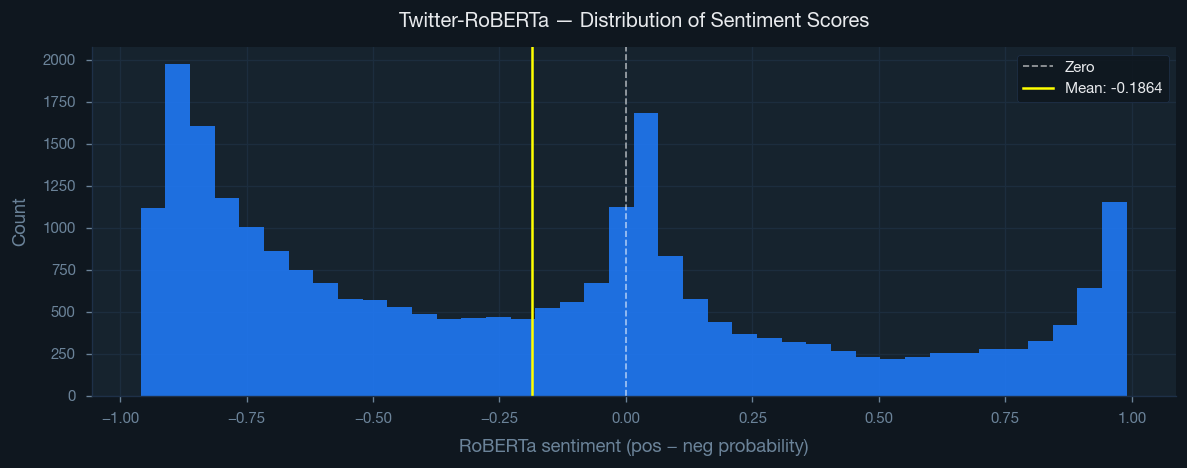

In [37]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
ax.hist(df['roberta_sentiment'], bins=40, color=DEMOCRAT, alpha=0.85, edgecolor='none')
ax.axvline(0, color='white', linestyle='--', linewidth=1, alpha=0.6, label='Zero')
ax.axvline(df['roberta_sentiment'].mean(), color='yellow', linewidth=1.5,
           label=f'Mean: {df["roberta_sentiment"].mean():.4f}')
ax.set_title('Twitter-RoBERTa — Distribution of Sentiment Scores', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_xlabel('RoBERTa sentiment (pos − neg probability)', color=TEXT_MUTED)
ax.set_ylabel('Count', color=TEXT_MUTED)
ax.tick_params(colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()


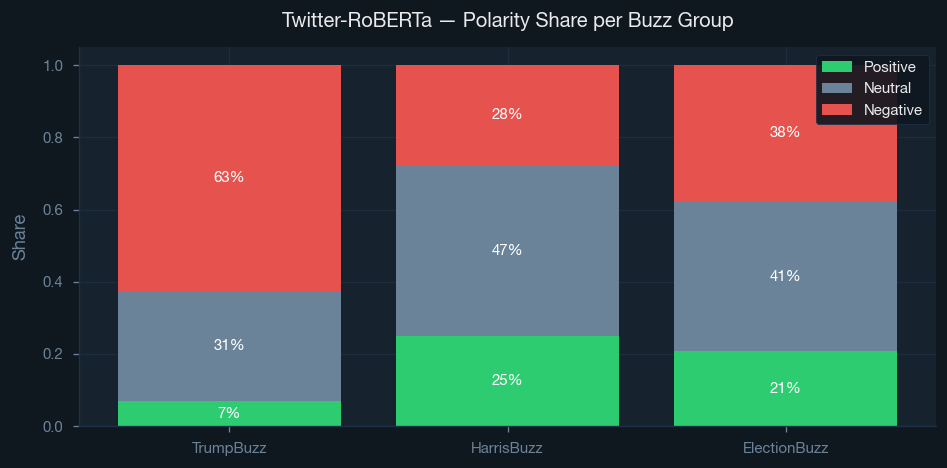

In [38]:
label_shares_g = (
    df.groupby(['buzz_group', 'roberta_label']).size()
      .unstack(fill_value=0)
      .apply(lambda r: r / r.sum(), axis=1)
      .reindex(BUZZ_ORDER)[['Positive', 'Neutral', 'Negative']]
)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
x, bottom = np.arange(len(BUZZ_ORDER)), np.zeros(len(BUZZ_ORDER))
for label, color in POL_COLORS.items():
    vals = label_shares_g[label].values
    ax.bar(x, vals, bottom=bottom, color=color, label=label, edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(x[i], b + v/2, f'{v:.0%}', ha='center', va='center', color='white', fontsize=9)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(BUZZ_ORDER, color=TEXT_MUTED)
ax.set_ylabel('Share', color=TEXT_MUTED)
ax.set_title('Twitter-RoBERTa — Polarity Share per Buzz Group', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.tick_params(colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY, loc='upper right')
plt.tight_layout()
plt.show()


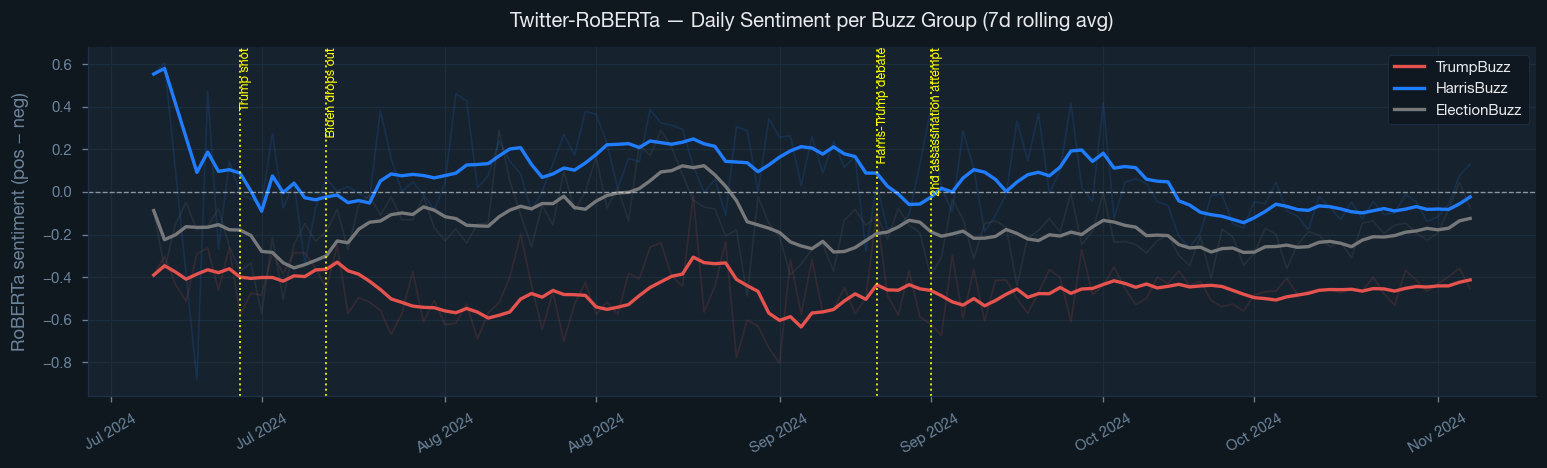

In [39]:
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
for group, color in BUZZ_COLORS.items():
    daily = df[df['buzz_group'] == group].groupby('date')['roberta_sentiment'].mean()
    roll  = daily.rolling(7, min_periods=1).mean()
    ax.plot(daily.index, daily.values, color=color, alpha=0.15, linewidth=1)
    ax.plot(roll.index,  roll.values,  color=color, linewidth=2, label=group)
ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
add_events(ax)
ax.set_title('Twitter-RoBERTa — Daily Sentiment per Buzz Group (7d rolling avg)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_ylabel('RoBERTa sentiment (pos − neg)', color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30, colors=TEXT_MUTED)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()


---
## 4. TextBlob

**What it is:** TextBlob uses the Pattern library lexicon to score text on two dimensions:
- `tb_polarity` ∈ [−1, +1] — how positive or negative the text is
- `tb_subjectivity` ∈ [0, 1] — how opinionated vs factual (0 = objective, 1 = subjective)

**Why after GloVe:** TextBlob uses a different underlying lexicon and handles multi-word expressions differently.
Its subjectivity score adds a dimension the other methods do not provide —
useful for separating opinion posts from factual reporting.

In [41]:
from textblob import TextBlob

tb = df['text_norm'].apply(lambda x: TextBlob(str(x)).sentiment)
df['tb_polarity']     = tb.apply(lambda s: s.polarity)
df['tb_subjectivity'] = tb.apply(lambda s: s.subjectivity)
df['tb_label']        = pd.cut(
    df['tb_polarity'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['Negative', 'Neutral', 'Positive']
)

print(df[['tb_polarity', 'tb_subjectivity']].describe().round(3))
print('\nPolarity distribution:')
print(df['tb_label'].value_counts())

       tb_polarity  tb_subjectivity
count    25472.000        25472.000
mean         0.061            0.358
std          0.287            0.312
min         -1.000            0.000
25%          0.000            0.000
50%          0.000            0.367
75%          0.200            0.583
max          1.000            1.000

Polarity distribution:
tb_label
Neutral     10465
Positive    10047
Negative     4960
Name: count, dtype: int64


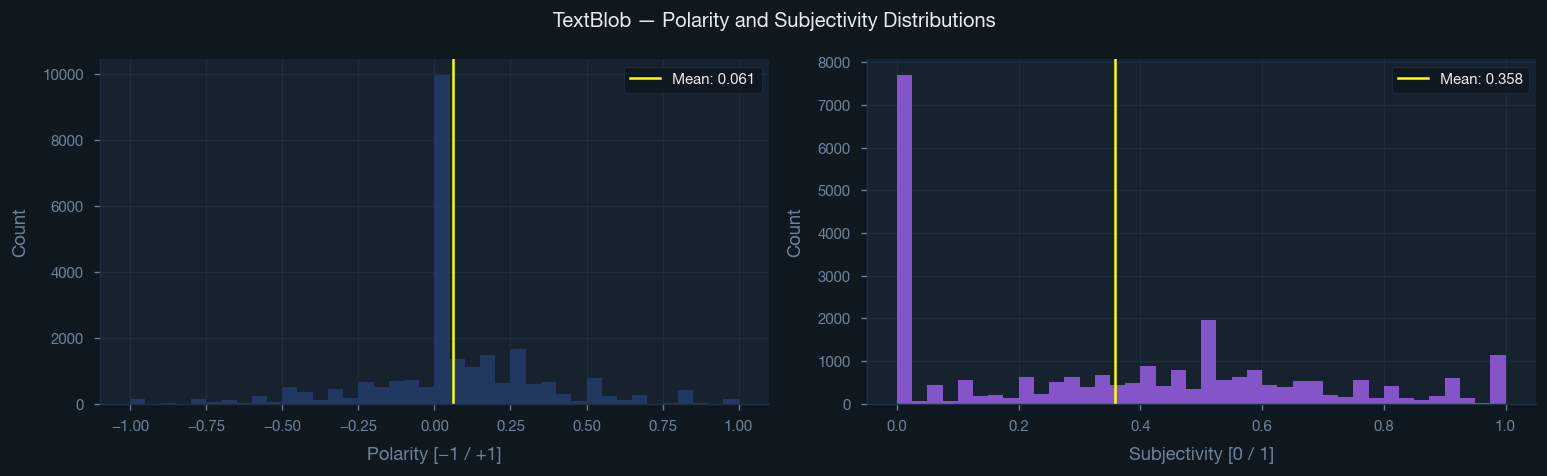

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('TextBlob — Polarity and Subjectivity Distributions', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')

for ax, col, label, color in [
    (axes[0], 'tb_polarity',     'Polarity [−1 / +1]',   ACCENT),
    (axes[1], 'tb_subjectivity', 'Subjectivity [0 / 1]', PURPLE),
]:
    ax.set_facecolor(BG_PANEL)
    ax.hist(df[col], bins=40, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(df[col].mean(), color='yellow', linewidth=1.5,
               label=f'Mean: {df[col].mean():.3f}')
    ax.set_xlabel(label, color=TEXT_MUTED)
    ax.set_ylabel('Count', color=TEXT_MUTED)
    ax.tick_params(colors=TEXT_MUTED)
    ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

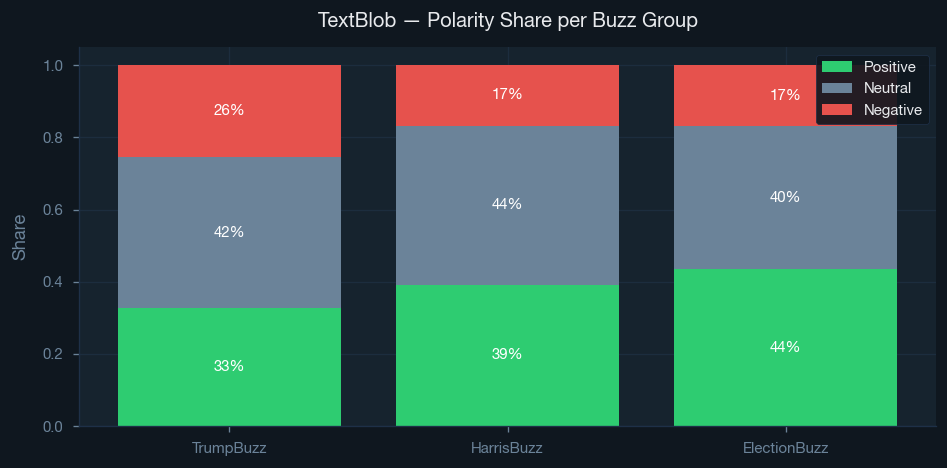

In [43]:
label_shares_tb = (
    df.groupby(['buzz_group', 'tb_label']).size()
      .unstack(fill_value=0)
      .apply(lambda r: r / r.sum(), axis=1)
      .reindex(BUZZ_ORDER)[['Positive', 'Neutral', 'Negative']]
)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
x, bottom = np.arange(len(BUZZ_ORDER)), np.zeros(len(BUZZ_ORDER))
for label, color in POL_COLORS.items():
    vals = label_shares_tb[label].values
    ax.bar(x, vals, bottom=bottom, color=color, label=label, edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(x[i], b + v/2, f'{v:.0%}', ha='center', va='center', color='white', fontsize=9)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(BUZZ_ORDER, color=TEXT_MUTED)
ax.set_ylabel('Share', color=TEXT_MUTED)
ax.set_title('TextBlob — Polarity Share per Buzz Group', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.tick_params(colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY, loc='upper right')
plt.tight_layout()
plt.show()

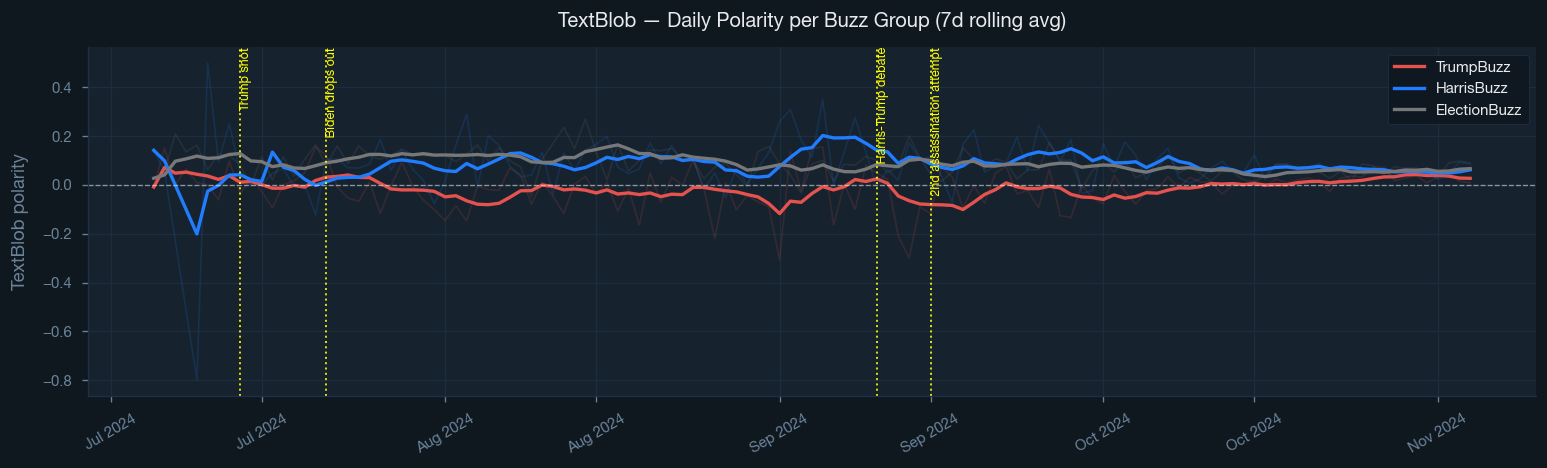

In [44]:
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
for group, color in BUZZ_COLORS.items():
    daily = df[df['buzz_group'] == group].groupby('date')['tb_polarity'].mean()
    roll  = daily.rolling(7, min_periods=1).mean()
    ax.plot(daily.index, daily.values, color=color, alpha=0.15, linewidth=1)
    ax.plot(roll.index,  roll.values,  color=color, linewidth=2, label=group)
ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
add_events(ax)
ax.set_title('TextBlob — Daily Polarity per Buzz Group (7d rolling avg)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_ylabel('TextBlob polarity', color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30, colors=TEXT_MUTED)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()

---
## 5. NRCLex — Emotion Detection

**What it is:** NRCLex maps words to 8 discrete emotions from Plutchik's wheel of emotions:
*fear, anger, anticipation, trust, surprise, sadness, disgust, joy*,
plus overall *positive* and *negative* labels.

**Why last:** NRCLex goes beyond polarity to capture *which* emotion is expressed —
important for understanding how people react to election events.
For example: the Trump assassination attempt may spike *fear* and *surprise*;
Biden's dropout may increase *anticipation* in HarrisBuzz posts.

In [45]:
from nrclex import NRCLex

def nrc_scores(text):
    af = NRCLex(str(text)).affect_frequencies
    return {e: af.get(e, 0) for e in EMOTION_COLS + ['positive', 'negative']}

print('Running NRCLex (may take a few minutes)...')
nrc_df = df['text_norm'].apply(nrc_scores).apply(pd.Series)
df     = pd.concat([df, nrc_df], axis=1)
df['nrc_sentiment'] = df['positive'] - df['negative']

print('Done.')
print(df[EMOTION_COLS].mean().round(4))

Running NRCLex (may take a few minutes)...
Done.
fear            0.0591
anger           0.0708
anticipation    0.0702
trust           0.1116
surprise        0.1264
sadness         0.0488
disgust         0.0388
joy             0.0499
dtype: float64


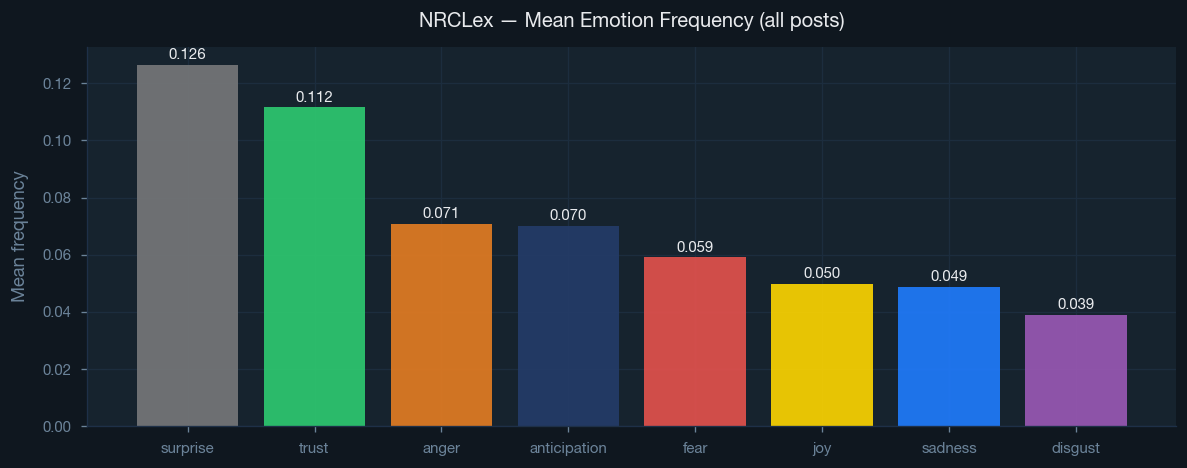

In [46]:
avg = df[EMOTION_COLS].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.bar(avg.index, avg.values,
              color=[EMOTION_COLORS[e] for e in avg.index],
              edgecolor='none', alpha=0.9)
for bar, val in zip(bars, avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f'{val:.3f}', ha='center', va='bottom', color=TEXT_PRIMARY, fontsize=9, fontweight='bold')
ax.set_title('NRCLex — Mean Emotion Frequency (all posts)', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_ylabel('Mean frequency', color=TEXT_MUTED)
ax.tick_params(colors=TEXT_MUTED)
plt.tight_layout()
plt.show()

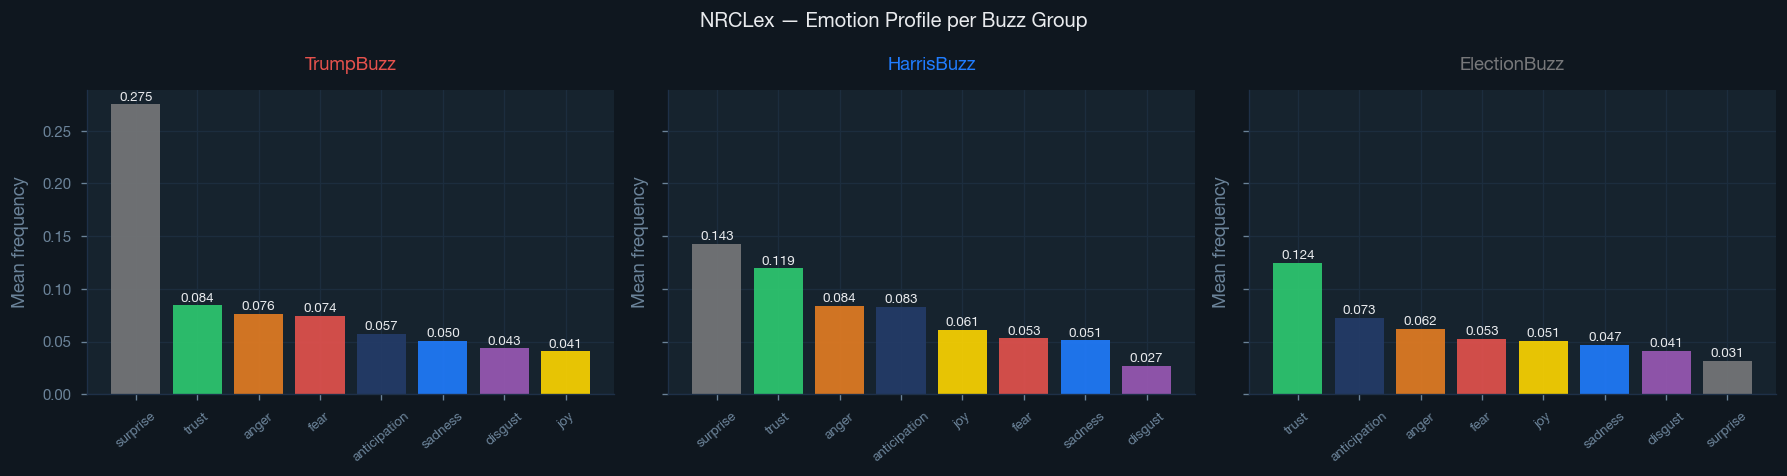

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('NRCLex — Emotion Profile per Buzz Group', color=TEXT_PRIMARY, fontsize=12, fontweight='bold')

for ax, group in zip(axes, BUZZ_ORDER):
    sub  = df[df['buzz_group'] == group][EMOTION_COLS].mean().sort_values(ascending=False)
    ax.set_facecolor(BG_PANEL)
    bars = ax.bar(sub.index, sub.values,
                  color=[EMOTION_COLORS[e] for e in sub.index],
                  edgecolor='none', alpha=0.9)
    for bar, val in zip(bars, sub.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', color=TEXT_PRIMARY, fontsize=8)
    ax.set_title(group, color=BUZZ_COLORS[group], fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean frequency', color=TEXT_MUTED)
    ax.tick_params(axis='x', rotation=40, colors=TEXT_MUTED, labelsize=8)
    ax.tick_params(axis='y', colors=TEXT_MUTED)

plt.tight_layout()
plt.show()

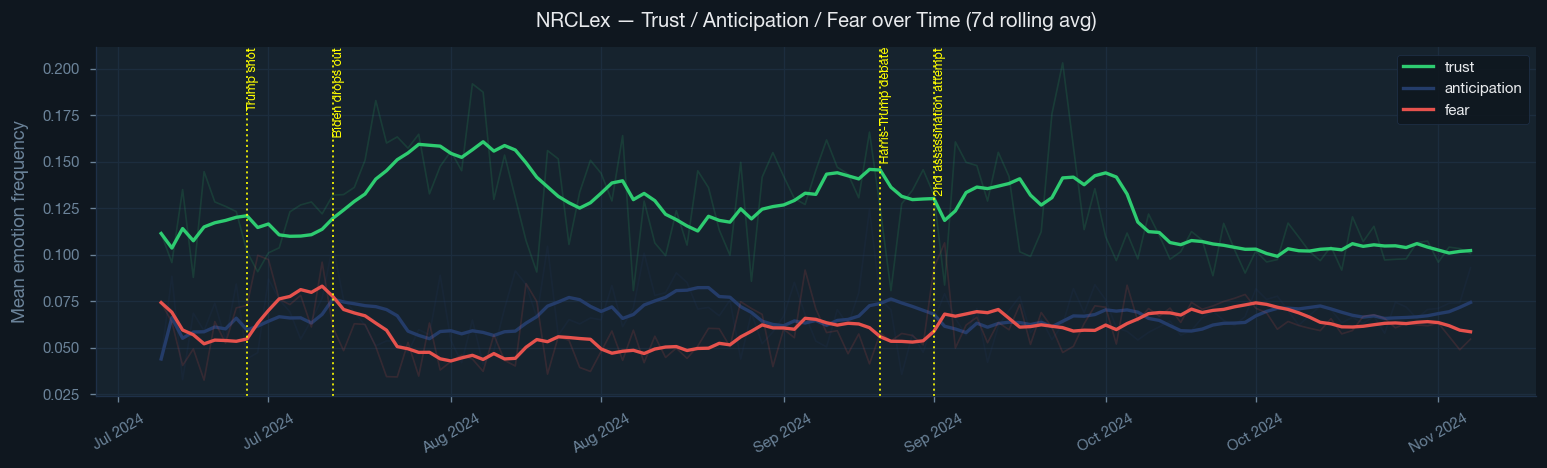

In [48]:
KEY_EMOTIONS = {'trust': '#2ecc71', 'anticipation': ACCENT, 'fear': REPUBLICAN}

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
for emotion, color in KEY_EMOTIONS.items():
    daily = df.groupby('date')[emotion].mean()
    roll  = daily.rolling(7, min_periods=1).mean()
    ax.plot(daily.index, daily.values, color=color, alpha=0.15, linewidth=1)
    ax.plot(roll.index,  roll.values,  color=color, linewidth=2, label=emotion)
add_events(ax)
ax.set_title('NRCLex — Trust / Anticipation / Fear over Time (7d rolling avg)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_ylabel('Mean emotion frequency', color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30, colors=TEXT_MUTED)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()

---
## 6. Method Comparison

How well do the four methods agree? We compare via a correlation matrix and a
z-scored overlay time series (so all methods are on the same scale).

In [51]:
sent_cols = {
    'VADER':    'vader_compound',
    'RoBERTa':  'roberta_sentiment',
    'TextBlob': 'tb_polarity',
    'NRCLex':   'nrc_sentiment',
}
corr = (
    df[[v for v in sent_cols.values()]]
    .rename(columns={v: k for k, v in sent_cols.items()})
    .corr()
)
print('Correlation matrix:')
print(corr.round(3))


Correlation matrix:
          VADER  RoBERTa  TextBlob  NRCLex
VADER     1.000    0.537     0.419   0.300
RoBERTa   0.537    1.000     0.405   0.307
TextBlob  0.419    0.405     1.000   0.272
NRCLex    0.300    0.307     0.272   1.000


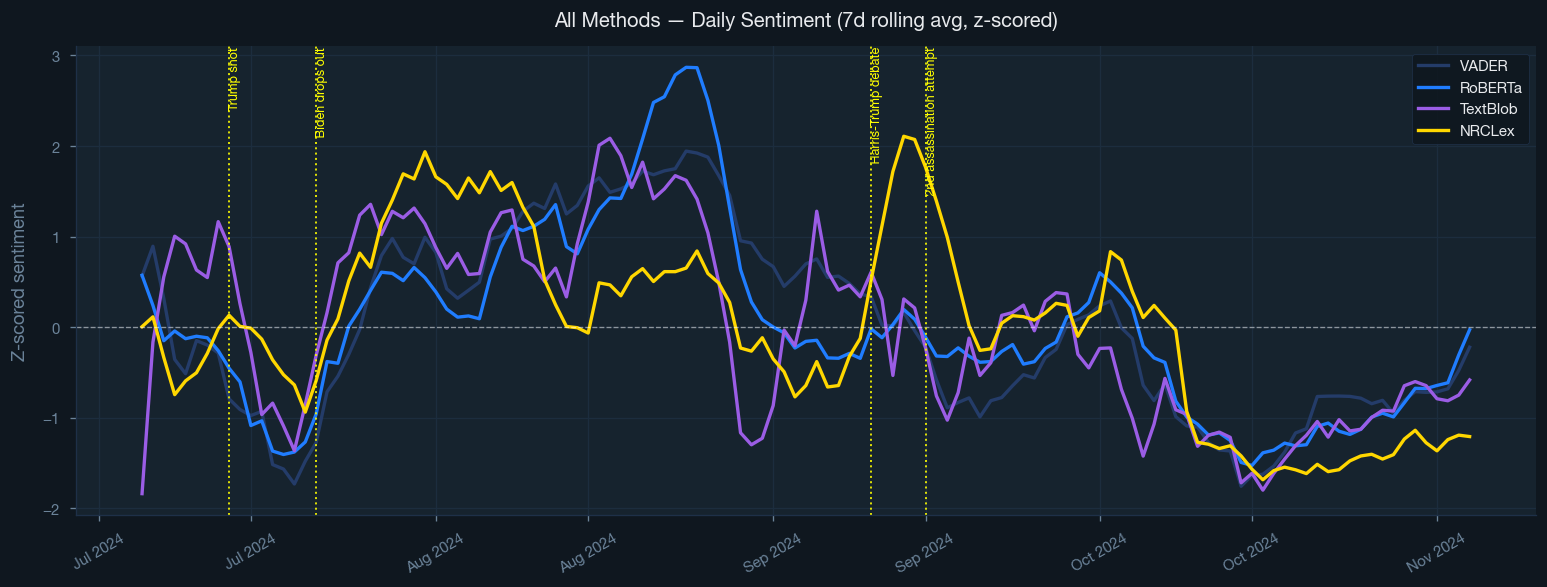

In [50]:
METHOD_COLORS = {'VADER': ACCENT, 'RoBERTa': DEMOCRAT, 'TextBlob': PURPLE, 'NRCLex': '#FFD700'}

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for label, col in sent_cols.items():
    daily = df.groupby('date')[col].mean()
    roll  = daily.rolling(7, min_periods=1).mean()
    z     = (roll - roll.mean()) / (roll.std() + 1e-8)   # z-score for comparability
    ax.plot(z.index, z.values, linewidth=2, label=label, color=METHOD_COLORS[label])

ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
add_events(ax)
ax.set_title('All Methods — Daily Sentiment (7d rolling avg, z-scored)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_ylabel('Z-scored sentiment', color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30, colors=TEXT_MUTED)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.legend(facecolor=BG_DARK, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()


---
## 7. Save enriched data

In [52]:
save_cols = [
    'date', 'buzz_group', 'text', 'text_norm',
    'roberta_sentiment', 'roberta_pos', 'roberta_neg', 'roberta_neu', 'roberta_label',
    'nrc_sentiment',
] + EMOTION_COLS

df[[c for c in save_cols if c in df.columns]].to_csv(OUT_PATH, index=False)
print(f'Saved {len(df):,} rows → {OUT_PATH}')

Saved 25,472 rows → ../../Data/2_Silver/Bluesky/sentiment_bluesky.csv
